In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
df_lyrics = pd.read_csv("clean_lyrics.csv")
df_peoms = pd.read_csv("poems.csv")

In [4]:
# pip install transformers torch pandas numpy

In [4]:
import torch

from transformers import AutoTokenizer, AutoConfig,XLMRobertaForSequenceClassification, PreTrainedModel
from torch import nn
from torch.nn import Dropout

# Define the CustomModel class which is predicting Both SENTIMENT POLARITY &  EMOTIONS
class CustomModel(XLMRobertaForSequenceClassification):
    def __init__(self, config, num_emotion_labels):
        super(CustomModel, self).__init__(config)
        self.num_emotion_labels = num_emotion_labels
        self.dropout_emotion = nn.Dropout(config.hidden_dropout_prob)
        self.emotion_classifier = nn.Sequential(
            nn.Linear(config.hidden_size, 512),
            nn.Mish(),
            nn.Dropout(0.3),
            nn.Linear(512, num_emotion_labels)
        )
        self._init_weights(self.emotion_classifier[0])
        self._init_weights(self.emotion_classifier[3])
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=self.config.initializer_range)
            if module.bias is not None:
                module.bias.data.zero_()
    def forward(self, input_ids=None, attention_mask=None, sentiment=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0]
        if len(sequence_output.shape) != 3:
            raise ValueError(f"Expected sequence_output to have 3 dimensions, got {sequence_output.shape}")
        cls_hidden_states = sequence_output[:, 0, :]
        cls_hidden_states = self.dropout_emotion(cls_hidden_states)
        emotion_logits = self.emotion_classifier(cls_hidden_states)
        with torch.no_grad():
            cls_token_state = sequence_output[:, 0, :].unsqueeze(1)
            sentiment_logits = self.classifier(cls_token_state).squeeze(1)
        if labels is not None:
            class_weights = torch.tensor([1.0] * self.num_emotion_labels).to(labels.device)
            loss_fct = nn.BCEWithLogitsLoss(pos_weight=class_weights)
            loss = loss_fct(emotion_logits, labels)
            return {"loss": loss, "emotion_logits": emotion_logits, "sentiment_logits": sentiment_logits}
        return {"emotion_logits": emotion_logits, "sentiment_logits": sentiment_logits}


# Load the tokenizer and model from the local directory
model_dir = "gsar78/HellenicSentimentAI_v2"
tokenizer = AutoTokenizer.from_pretrained(model_dir)
config = AutoConfig.from_pretrained(model_dir)
model = CustomModel.from_pretrained(model_dir, config=config, num_emotion_labels=18)


# Function to predict sentiment and emotion
def predict(texts):
    # Tokenize the input texts
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=512)

    # Move inputs to the same device as the model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Ensure the model is on the correct device
    model.to(device)
    model.eval()  # Set the model to evaluation mode

    # Clear any gradients
    model.zero_grad()

    # Get model predictions
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract logits
    emotion_logits = outputs["emotion_logits"]
    sentiment_logits = outputs["sentiment_logits"]

    # Convert logits to probabilities
    emotion_probs = torch.sigmoid(emotion_logits)
    sentiment_probs = torch.softmax(sentiment_logits, dim=1)

    # Convert tensors to lists for easier handling
    emotion_probs_list = (emotion_probs * 100).tolist()[0]  # Get the first (and only) sample and convert to %
    sentiment_probs_list = (sentiment_probs * 100).tolist()[0]  # Get the first (and only) sample and convert to %

    # Define the sentiment and emotion labels
    sentiment_labels = ['negative', 'neutral', 'positive']
    emotion_labels = [
        'joy', 'trust', 'excitement', 'gratitude', 'hope', 'love', 'pride',
        'anger', 'disgust', 'fear', 'sadness', 'anxiety', 'frustration', 'guilt',
        'disappointment', 'surprise', 'anticipation', 'neutral'
    ]

    # Threshold for displaying probabilities
    threshold = 0.0

    # Map emotion probabilities to their corresponding labels
    emotion_results = {label: prob for label, prob in zip(emotion_labels, emotion_probs_list) if prob > 0.30}

    # Map sentiment probabilities to their corresponding labels
    sentiment_results = {label: prob for label, prob in zip(sentiment_labels, sentiment_probs_list) if prob > threshold}

    return emotion_results, sentiment_results

def predict_row(text):
    if not isinstance(text, str) or not text.strip():
        return {}
    
    # Tokenize (single input, not a list)
    inputs = tokenizer(text, padding = True, truncation = True, return_tensors="pt", max_length=512)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # Calculate Probabilities
    emotion_probs = torch.sigmoid(outputs["emotion_logits"])
    sentiment_probs = torch.softmax(outputs["sentiment_logits"], dim=1)

    # Convert to standard Python lists (x100 for percentage)
    e_probs = (emotion_probs * 100).tolist()[0]
    s_probs = (sentiment_probs * 100).tolist()[0]

    # --- THE KEY CHANGE: FLAT DICTIONARY & NO THRESHOLD ---
    row_data = {}
    
    # Labels
    sentiment_labels = ['negative', 'neutral', 'positive']
    emotion_labels = [
        'joy', 'trust', 'excitement', 'gratitude', 'hope', 'love', 'pride',
        'anger', 'disgust', 'fear', 'sadness', 'anxiety', 'frustration', 'guilt',
        'disappointment', 'surprise', 'anticipation', 'neutral'
    ]

    # Add Sentiments with prefix
    for label, prob in zip(sentiment_labels, s_probs):
        row_data[f"sent_{label}"] = prob  # e.g., sent_positive
        
    # Add Emotions with prefix
    for label, prob in zip(emotion_labels, e_probs):
        row_data[f"emo_{label}"] = prob   # e.g., emo_anger

    return row_data


Loading weights:   0%|          | 0/205 [00:00<?, ?it/s]

In [30]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

# --- CONFIGURATION ---
BATCH_SIZE = 50       # Process 50 songs at a time (adjust based on your RAM)
OUTPUT_FILE = "sentiment.csv"

# Ensure tqdm works with pandas
tqdm.pandas()

print(f"Starting batch processing... Saving to '{OUTPUT_FILE}'")

# Check if file exists to determine if we need to write headers
# If you want to restart from scratch, delete the file 'greek_lyrics_analyzed_partial.csv' manually first!
if os.path.exists(OUTPUT_FILE):
    print(f"Warning: '{OUTPUT_FILE}' already exists. New data will be appended.")

# --- BATCH LOOP ---
total_rows = len(df_lyrics)
# We loop from 0 to total_rows in steps of BATCH_SIZE
for i in tqdm(range(5000, total_rows, BATCH_SIZE), desc="Processing Batches"):

    # 1. Slice the dataframe (Get the next 50 songs)
    batch = df_lyrics.iloc[i : i + BATCH_SIZE].copy()

    try:
        # 2. Apply your prediction function
        # This returns a Series of dictionaries
        predictions_series = batch['clean_lyrics'].apply(predict_row)

        # 3. Convert that Series of dicts into a proper DataFrame with columns
        # list(predictions_series) is faster than applying pd.Series row-by-row
        predictions_df = pd.DataFrame(list(predictions_series))

        # 4. Concatenate the original info (Genre, Title) with the New Scores
        # We must reset index to ensure they align perfectly
        batch_final = pd.concat([
            batch.reset_index(drop=True), 
            predictions_df.reset_index(drop=True)
        ], axis=1)

        # 5. Save to CSV
        # mode='a' means APPEND (add to the end of the file)
        # header=... We only write the header (column names) for the very first batch
        is_first_batch = (i == 0)
        
        # If the file doesn't exist yet, we must write headers.
        # If it does exist, we skip headers so we don't have headers in the middle of the file.
        write_header = is_first_batch or not os.path.exists(OUTPUT_FILE)
        
        batch_final.to_csv(OUTPUT_FILE, mode='a', header=write_header, index=False)
        
    except Exception as e:
        print(f"Error processing batch starting at index {i}: {e}")
        # Option: Save the 'bad' batch to a separate file to debug later
        # batch.to_csv(f"error_batch_{i}.csv")

print("\nProcessing complete!")
print(f"All data saved to: {OUTPUT_FILE}")

Starting batch processing... Saving to 'sentiment.csv'


Processing Batches: 100%|██████████| 23/23 [16:45<00:00, 43.72s/it]


Processing complete!
All data saved to: sentiment.csv


In [29]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

# --- CONFIGURATION ---
BATCH_SIZE = 50       # Process 50 songs at a time (adjust based on your RAM)
OUTPUT_FILE = "poems_sentiment.csv"

# Ensure tqdm works with pandas
tqdm.pandas()

print(f"Starting batch processing... Saving to '{OUTPUT_FILE}'")

# Check if file exists to determine if we need to write headers
# If you want to restart from scratch, delete the file 'greek_lyrics_analyzed_partial.csv' manually first!
if os.path.exists(OUTPUT_FILE):
    print(f"Warning: '{OUTPUT_FILE}' already exists. New data will be appended.")

# --- BATCH LOOP ---
total_rows = len(df_peoms)
# We loop from 0 to total_rows in steps of BATCH_SIZE
for i in tqdm(range(3000, total_rows, BATCH_SIZE), desc="Processing Batches"):
    
    # 1. Slice the dataframe (Get the next 50 songs)
    batch = df_peoms.iloc[i : i + BATCH_SIZE].copy()
    
    try:
        # 2. Apply your prediction function
        # This returns a Series of dictionaries
        predictions_series = batch['Lyrics'].apply(predict_row)
        
        # 3. Convert that Series of dicts into a proper DataFrame with columns
        # list(predictions_series) is faster than applying pd.Series row-by-row
        predictions_df = pd.DataFrame(list(predictions_series))
        
        # 4. Concatenate the original info (Genre, Title) with the New Scores
        # We must reset index to ensure they align perfectly
        batch_final = pd.concat([
            batch.reset_index(drop=True), 
            predictions_df.reset_index(drop=True)
        ], axis=1)
        
        # 5. Save to CSV
        # mode='a' means APPEND (add to the end of the file)
        # header=... We only write the header (column names) for the very first batch
        is_first_batch = (i == 0)
        
        # If the file doesn't exist yet, we must write headers.
        # If it does exist, we skip headers so we don't have headers in the middle of the file.
        write_header = is_first_batch or not os.path.exists(OUTPUT_FILE)
        
        batch_final.to_csv(OUTPUT_FILE, mode='a', header=write_header, index=False)
        
    except Exception as e:
        print(f"Error processing batch starting at index {i}: {e}")
        # Option: Save the 'bad' batch to a separate file to debug later
        # batch.to_csv(f"error_batch_{i}.csv")

print("\nProcessing complete!")
print(f"All data saved to: {OUTPUT_FILE}")

Starting batch processing... Saving to 'poems_sentiment.csv'


Processing Batches: 100%|██████████| 4/4 [01:07<00:00, 16.83s/it]


Processing complete!
All data saved to: poems_sentiment.csv


In [ ]:
dfp = pd.read_csv("poems_sentiment.csv")
dfr = pd.read_csv("sentiment.csv")
dfr = dfr.drop(columns = ['album', 'annotation_count', 'featured_artists' ,'lyrics', 'date', 'pageviews', 'num_intros', 'num_verses', 'num_choruses', 
'num_pre_chorus', 'num_bridges', 'num_outros', 'num_instrumentals', 'line_count', 'word_count', 'unique_word_count', 'lexical_diversity'])
dfr = dfr.rename(columns = {'clean_lyrics': 'lyrics'})
dfp = dfp.rename(columns = {'Poet' : 'artist', 'Title': 'title', 'Lyrics': 'lyrics'})
dfp = dfp.drop(columns = ['Author_ID', 'Poem_ID'])
dfp['genre'] = 'poem'
dfr['genre'] = 'rap'
df = pd.concat([dfr, dfp])

calculate the average emotions

In [121]:
import pandas as pd

# Identify all your emotion and sentiment columns automatically
score_cols = [col for col in df.columns if col.startswith('emo_') or col.startswith('sent_')]

# Calculate the mean (average) for each genre
averages = df.groupby('genre')[score_cols].mean()

# Transpose (.T) so it prints beautifully with emotions as rows and genres as columns
print("--- AVERAGE SCORES PER GENRE ---")
print(round(averages.T * 100)) # Multiplying by 100 to read them as percentages

--- AVERAGE SCORES PER GENRE ---
genre                 poem     rap
sent_negative       3304.0  3396.0
sent_neutral        3287.0  3141.0
sent_positive       3409.0  3463.0
emo_joy             5179.0  5179.0
emo_trust           5160.0  5071.0
emo_excitement      5406.0  5208.0
emo_gratitude       4854.0  4912.0
emo_hope            5122.0  5181.0
emo_love            4937.0  5098.0
emo_pride           5155.0  5095.0
emo_anger           4996.0  5113.0
emo_disgust         5008.0  5038.0
emo_fear            5258.0  5056.0
emo_sadness         4860.0  5016.0
emo_anxiety         4488.0  4792.0
emo_frustration     4800.0  5131.0
emo_guilt           5014.0  5200.0
emo_disappointment  5321.0  5166.0
emo_surprise        4851.0  4829.0
emo_anticipation    5259.0  5029.0
emo_neutral         4745.0  4879.0


4


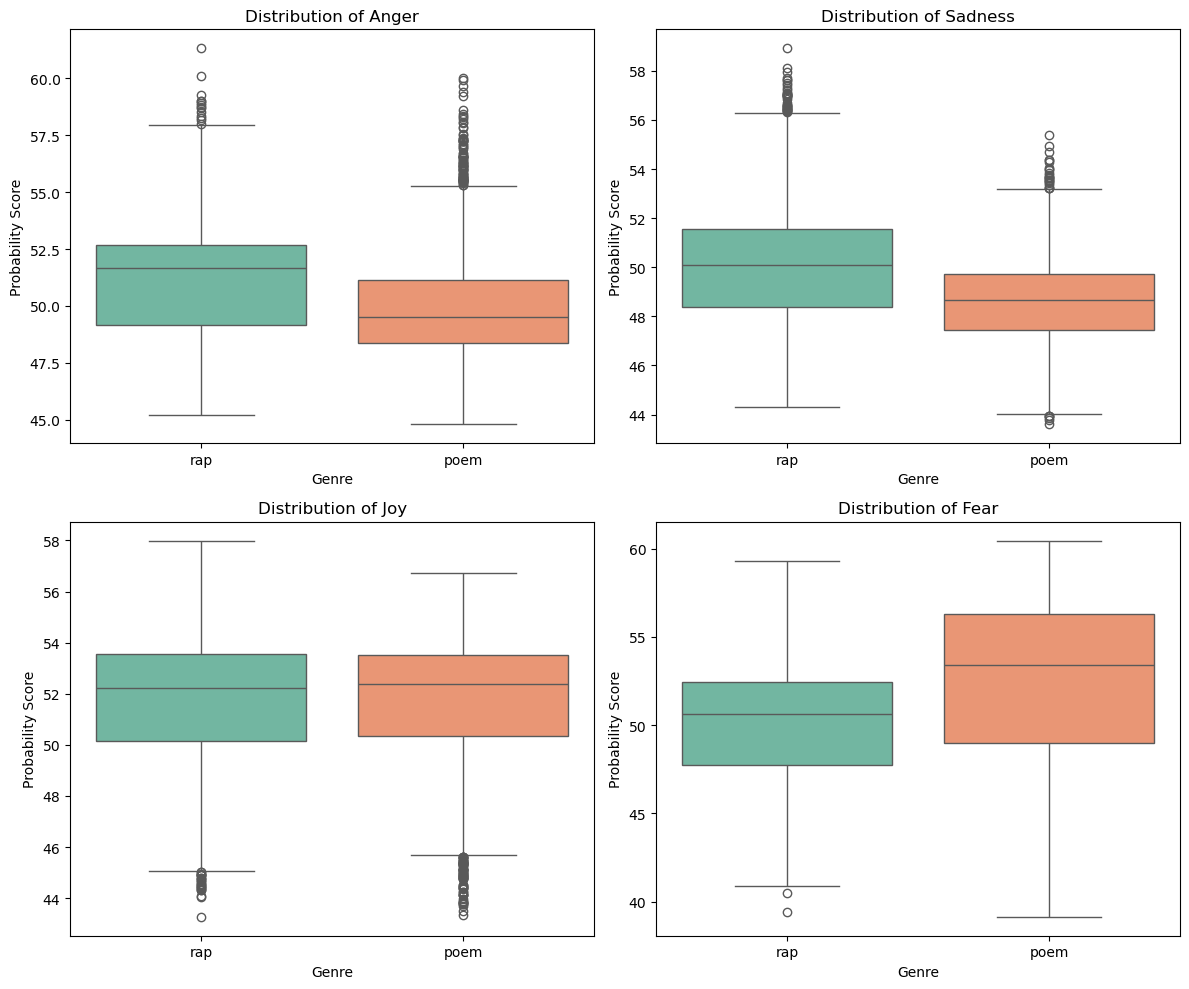

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- THE FIX ---
# This cleans up the row numbers so there are no duplicates
df = df.reset_index(drop=True)

# Let's pick 4 interesting emotions to compare visually
emotion_cols = [col for col in df.columns if col.startswith('emo_')]
emotion_cols = ['emo_anger', 'emo_sadness', 'emo_joy', 'emo_fear']
print(len(emotion_cols))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, emo in enumerate(emotion_cols):
    sns.boxplot(
        x='genre', 
        y=emo, 
        data=df, 
        ax=axes[i], 
        hue='genre', 
        palette="Set2", 
        legend=False
    )
    axes[i].set_title(f'Distribution of {emo.replace("emo_", "").capitalize()}')
    axes[i].set_ylabel('Probability Score')
    axes[i].set_xlabel('Genre')

plt.tight_layout()
plt.show()

statistical proof - t test

In [123]:
from scipy import stats

print("\n--- STATISTICAL SIGNIFICANCE (T-TESTS) ---")
significant_findings = []

for col in score_cols:
    # Isolate the scores for rap and poems
    rap_scores = df[df['genre'] == 'rap'][col]
    poem_scores = df[df['genre'] == 'poem'][col]
    
    # Run the T-test (equal_var=False is Welch's t-test, safer for real-world data)
    t_stat, p_value = stats.ttest_ind(rap_scores, poem_scores, equal_var=False, nan_policy='omit')
    
    # If p-value is less than 0.05, the difference is statistically significant!
    if p_value < 0.05:
        # Check who has the higher average to formulate the sentence
        rap_mean = rap_scores.mean()
        poem_mean = poem_scores.mean()
        winner = "Rap" if rap_mean > poem_mean else "Poems"
        
        print(f"✅ {col.upper()}: Significant! ({winner} is higher. p-value: {p_value:.4f})")
        significant_findings.append(col)
    else:
        print(f"❌ {col.upper()}: Not significantly different (p-value: {p_value:.4f})")


--- STATISTICAL SIGNIFICANCE (T-TESTS) ---
✅ SENT_NEGATIVE: Significant! (Rap is higher. p-value: 0.0000)
✅ SENT_NEUTRAL: Significant! (Poems is higher. p-value: 0.0000)
✅ SENT_POSITIVE: Significant! (Rap is higher. p-value: 0.0000)
❌ EMO_JOY: Not significantly different (p-value: 0.9410)
✅ EMO_TRUST: Significant! (Poems is higher. p-value: 0.0000)
✅ EMO_EXCITEMENT: Significant! (Poems is higher. p-value: 0.0000)
✅ EMO_GRATITUDE: Significant! (Rap is higher. p-value: 0.0000)
✅ EMO_HOPE: Significant! (Rap is higher. p-value: 0.0000)
✅ EMO_LOVE: Significant! (Rap is higher. p-value: 0.0000)
✅ EMO_PRIDE: Significant! (Poems is higher. p-value: 0.0000)
✅ EMO_ANGER: Significant! (Rap is higher. p-value: 0.0000)
✅ EMO_DISGUST: Significant! (Rap is higher. p-value: 0.0000)
✅ EMO_FEAR: Significant! (Poems is higher. p-value: 0.0000)
✅ EMO_SADNESS: Significant! (Rap is higher. p-value: 0.0000)
✅ EMO_ANXIETY: Significant! (Rap is higher. p-value: 0.0000)
✅ EMO_FRUSTRATION: Significant! (Rap is 

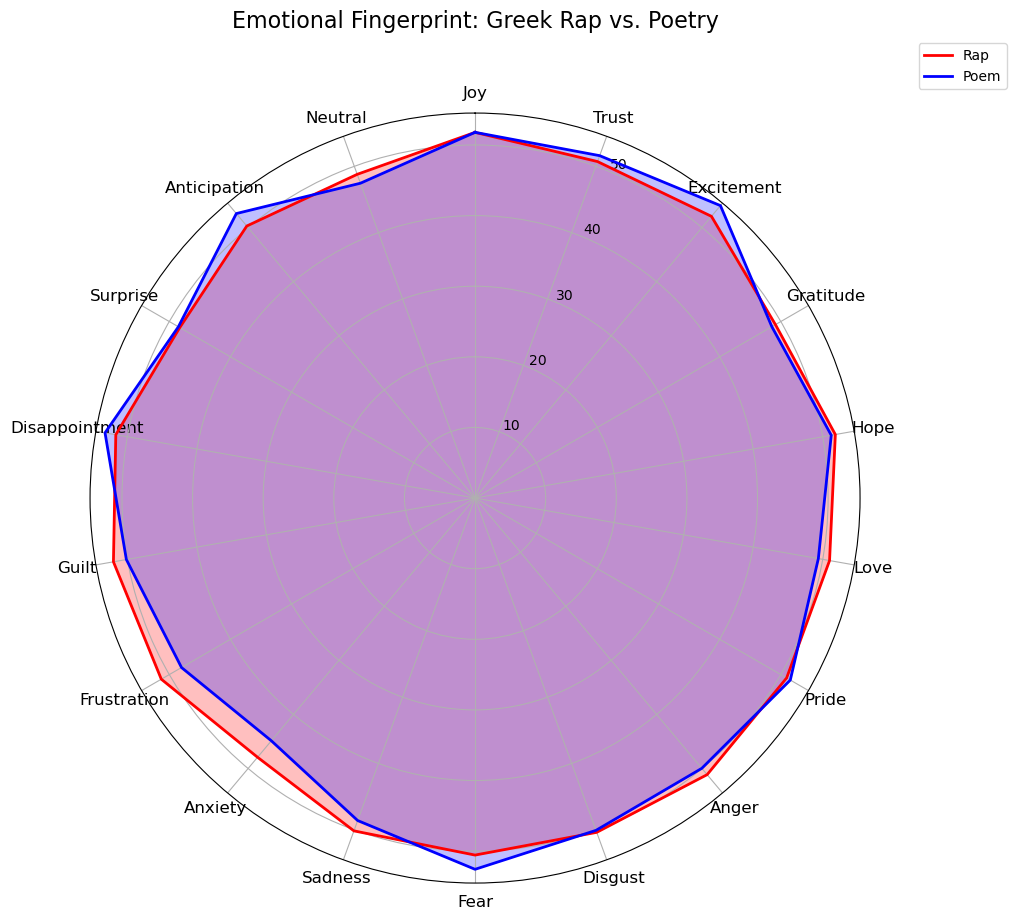

In [124]:
import numpy as np

def plot_radar_chart(df, genre_col='genre', score_cols=None):
    if not score_cols:
        # Filter only emotion columns (ignore sentiment polarity for the radar)
        score_cols = [c for c in df.columns if c.startswith('emo_')]
        
    # Get averages
    means = df.groupby(genre_col)[score_cols].mean()
    
    # Clean labels (e.g., 'emo_anger' -> 'Anger')
    labels = [c.replace('emo_', '').capitalize() for c in score_cols]
    num_vars = len(labels)
    
    # Compute angles for the radar
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] # Close the loop
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Colors for our genres
    colors = {'rap': 'red', 'poem': 'blue'}
    
    for genre in ['rap', 'poem']:
        values = means.loc[genre].tolist()
        values += values[:1] # Close the loop
        
        ax.plot(angles, values, color=colors[genre], linewidth=2, label=genre.capitalize())
        ax.fill(angles, values, color=colors[genre], alpha=0.25)
        
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)
    
    plt.title("Emotional Fingerprint: Greek Rap vs. Poetry", size=16, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

# Run it!
plot_radar_chart(df)